## 1. Импорты, seed, устройство


In [1]:
import random
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── seed ──────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

# ── artifact dirs ─────────────────────────────────────────────────────────────
os.makedirs('artifacts/figures', exist_ok=True)

device: cuda


## 2. Данные и первичный анализ


In [2]:
df = pd.read_csv('S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print('Размер датасета:', df.shape)
print('Диапазон дат   :', df['date'].min(), '—', df['date'].max())
print('\nПропуски по колонкам:')
print(df.isnull().sum())

Размер датасета: (4320, 2)
Диапазон дат   : 2025-01-01 00:00:00 — 2025-06-29 23:00:00

Пропуски по колонкам:
date      0
target    0
dtype: int64


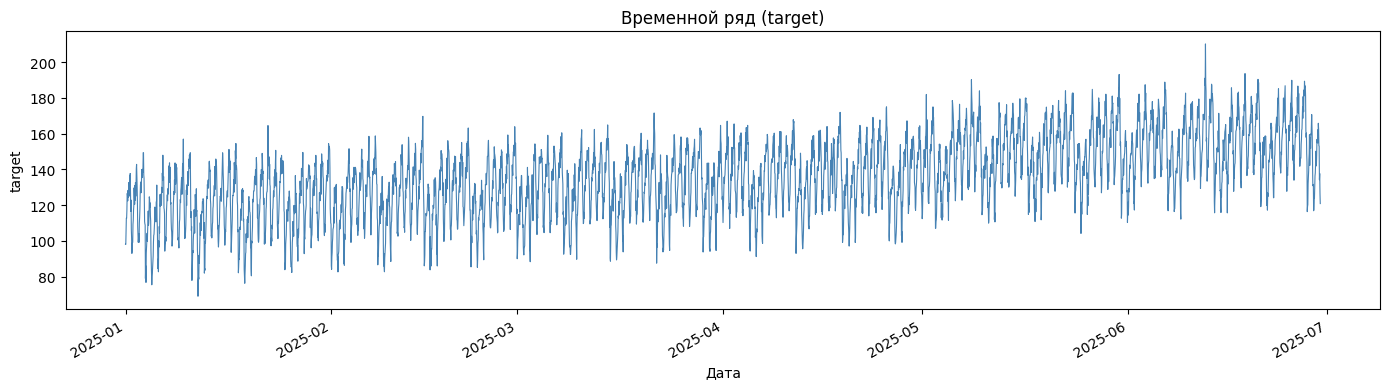

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['target'], linewidth=0.8, color='steelblue')
ax.set_title('Временной ряд (target)')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('artifacts/figures/series_raw.png', dpi=150)
plt.show()

**Комментарий по ряду** (заполнить вручную после просмотра):
- Тренд:  явный восходящий.
- Сезонность: регулярная
- Выбросы: возможны в июне-июле (пики > 200)
- Нестационарность: присутствует (из-за тренда)


## 3. Temporal split


In [4]:
n = len(df)
# 70% train, 15% validation, 15% test
train_end   = int(n * 0.70)
val_end     = int(n * 0.85)

df_train = df.iloc[:train_end].copy()
df_val   = df.iloc[train_end:val_end].copy()
df_test  = df.iloc[val_end:].copy()

print(f'Train : {df_train["date"].min().date()} — {df_train["date"].max().date()}  ({len(df_train)} obs)')
print(f'Val   : {df_val["date"].min().date()} — {df_val["date"].max().date()}  ({len(df_val)} obs)')
print(f'Test  : {df_test["date"].min().date()} — {df_test["date"].max().date()}  ({len(df_test)} obs)')

Train : 2025-01-01 — 2025-05-06  (3024 obs)
Val   : 2025-05-07 — 2025-06-02  (648 obs)
Test  : 2025-06-03 — 2025-06-29  (648 obs)


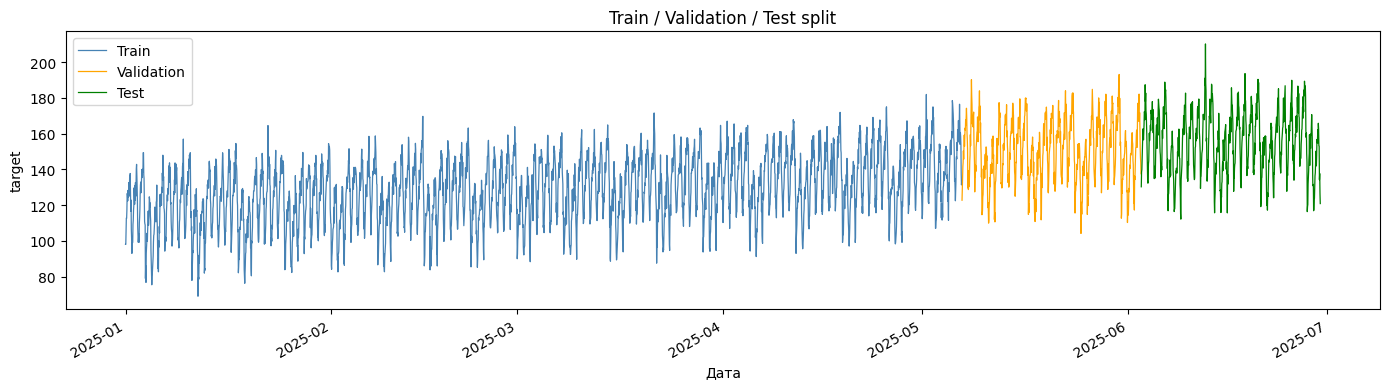


Почему random split некорректен:
При случайном перемешивании будущие значения ряда попадают в train, а прошлые — в test.
Модель получает информацию о будущем и показывает искусственно заниженную ошибку.
На реальных данных такая модель будет давать плохие прогнозы. Temporal split
гарантирует, что модель обучается только на данных, предшествующих точке прогноза.



In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_train['date'], df_train['target'], label='Train', color='steelblue', lw=0.9)
ax.plot(df_val['date'],   df_val['target'],   label='Validation', color='orange', lw=0.9)
ax.plot(df_test['date'],  df_test['target'],  label='Test', color='green', lw=0.9)
ax.legend()
ax.set_title('Train / Validation / Test split')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=150)
plt.show()

print("""
Почему random split некорректен:
При случайном перемешивании будущие значения ряда попадают в train, а прошлые — в test.
Модель получает информацию о будущем и показывает искусственно заниженную ошибку.
На реальных данных такая модель будет давать плохие прогнозы. Temporal split
гарантирует, что модель обучается только на данных, предшествующих точке прогноза.
""")

## 4. Feature engineering


In [6]:
def make_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Добавляет лаговые, rolling и календарные признаки.
    NaN-строки, появившиеся из-за lag/rolling, не удаляются здесь —
    это делается снаружи после конкатенации, чтобы не нарушить индексы сплитов.
    """
    f = frame.copy()
    # lag-признаки
    f['lag_1']  = f['target'].shift(1)
    f['lag_7']  = f['target'].shift(7)
    f['lag_14'] = f['target'].shift(14)
    # rolling-признаки (min_periods=1, чтобы не терять строки на краю)
    f['rolling_mean_7'] = f['target'].shift(1).rolling(7, min_periods=1).mean()
    f['rolling_std_7']  = f['target'].shift(1).rolling(7, min_periods=1).std().fillna(0)
    # календарные признаки
    f['day_of_week'] = f['date'].dt.dayofweek          # 0=Mon, 6=Sun
    f['month']       = f['date'].dt.month
    f['day_of_month']= f['date'].dt.day
    return f

# строим признаки на полном датафрейме, чтобы границы не ломали shift
df_feat = make_features(df)
df_feat = df_feat.dropna().reset_index(drop=True)

# переопределяем сплиты на датафрейме с признаками
n_f = len(df_feat)
train_end_f = int(n_f * 0.70)
val_end_f   = int(n_f * 0.85)

df_train_f = df_feat.iloc[:train_end_f].copy()
df_val_f   = df_feat.iloc[train_end_f:val_end_f].copy()
df_test_f  = df_feat.iloc[val_end_f:].copy()

FEATURE_COLS = ['lag_1', 'lag_7', 'lag_14',
                'rolling_mean_7', 'rolling_std_7',
                'day_of_week', 'month', 'day_of_month']

print('Итоговое число признаков:', len(FEATURE_COLS))
df_feat[FEATURE_COLS + ['target']].head()

Итоговое число признаков: 8


,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,day_of_week,month,day_of_month,target
0,125.04,126.01,98.14,126.445714,3.275621,2,1,1,128.87
1,128.87,122.38,98.07,126.854286,3.388632,2,1,1,136.40
2,136.40,128.28,104.70,128.857143,4.318919,2,1,1,133.85
3,133.85,124.43,112.81,129.652857,4.691868,2,1,1,137.71
4,137.71,126.35,112.62,131.550000,4.907936,2,1,1,126.32


## 5. Метрики


In [7]:
def mape(y_true, y_pred, eps=1e-8):
    return float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps)))) * 100

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mp   = mape(np.array(y_true), np.array(y_pred))
    return dict(mae=mae, rmse=rmse, mape=mp)

## 6. B1 — Naive Last


In [8]:
# Прогноз = последнее значение train (lag_1 для val/test)
val_pred_b1  = df_val_f['lag_1'].values
test_pred_b1 = df_test_f['lag_1'].values

b1_val  = compute_metrics(df_val_f['target'].values,  val_pred_b1)
b1_test = compute_metrics(df_test_f['target'].values, test_pred_b1)
print('B1 val :', b1_val)
print('B1 test:', b1_test)

B1 val : {'mae': 6.4434055727554185, 'rmse': np.float64(8.20353204909296), 'mape': 4.3945939598176125}
B1 test: {'mae': 6.338018575851392, 'rmse': np.float64(8.059905622137947), 'mape': 4.143508378725092}


## 7. B2 — Moving Average


In [10]:
val_pred_b2  = df_val_f['rolling_mean_7'].values
test_pred_b2 = df_test_f['rolling_mean_7'].values

b2_val  = compute_metrics(df_val_f['target'].values,  val_pred_b2)
b2_test = compute_metrics(df_test_f['target'].values, test_pred_b2)
print('B2 val :', b2_val)
print('B2 test:', b2_test)

B2 val : {'mae': 12.723717381689518, 'rmse': np.float64(15.236325500475134), 'mape': 8.828779373204593}
B2 test: {'mae': 12.725249889429454, 'rmse': np.float64(15.226178942983882), 'mape': 8.534403399316336}


## 8. B3 — Ridge на лаговых признаках


In [11]:
# Только на train!
scaler = StandardScaler()
train_target = df_train_f['target'].values.reshape(-1, 1)
scaler.fit(train_target)

df_train_f['target_scaled'] = scaler.transform(train_target)
df_val_f['target_scaled']   = scaler.transform(df_val_f['target'].values.reshape(-1, 1))
df_test_f['target_scaled']  = scaler.transform(df_test_f['target'].values.reshape(-1, 1))

In [12]:
X_train = df_train_f[FEATURE_COLS].values
y_train = df_train_f['target'].values
X_val   = df_val_f[FEATURE_COLS].values
y_val   = df_val_f['target'].values
X_test  = df_test_f[FEATURE_COLS].values
y_test  = df_test_f['target'].values

# масштабируем только на train
scaler_x = StandardScaler()
X_train_s = scaler_x.fit_transform(X_train)
X_val_s   = scaler_x.transform(X_val)
X_test_s  = scaler_x.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)

val_pred_b3  = ridge.predict(X_val_s)
test_pred_b3 = ridge.predict(X_test_s)

b3_val  = compute_metrics(y_val,  val_pred_b3)
b3_test = compute_metrics(y_test, test_pred_b3)
print('B3 val :', b3_val)
print('B3 test:', b3_test)

B3 val : {'mae': 6.341245180091853, 'rmse': np.float64(7.935198901390998), 'mape': 4.245655279694526}
B3 test: {'mae': 6.006511171916846, 'rmse': np.float64(7.687072610799954), 'mape': 3.8655574190144795}


## 9. R1 — GRU


In [13]:
WINDOW_SIZE = 14
HIDDEN_SIZE = 64
NUM_LAYERS  = 2
BATCH_SIZE  = 32
LR          = 1e-3
EPOCHS      = 50

# Правильный вариант — fit только на train
scaler_y = StandardScaler()
scaler_y.fit(df_train_f[['target']].values)   # ← только train!

y_all_scaled = scaler_y.transform(df_feat[['target']].values).flatten()

# индексы сплитов в df_feat
train_idx = np.arange(0, train_end_f)
val_idx   = np.arange(train_end_f, val_end_f)
test_idx  = np.arange(val_end_f, n_f)

In [14]:
class TimeSeriesDataset(Dataset):
    def __init__(self, series, indices, window):
        """
        series  : массив масштабированных значений target (весь ряд)
        indices : индексы строк, которые могут быть таргетом (не ранее window)
        window  : длина входного окна
        """
        self.series  = series
        self.window  = window
        # оставляем только те индексы, для которых есть полное окно
        self.targets = [i for i in indices if i >= window]

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        t = self.targets[idx]
        x = self.series[t - self.window : t]          # (window,)
        y = self.series[t]                              # scalar
        return torch.tensor(x, dtype=torch.float32).unsqueeze(-1), torch.tensor(y, dtype=torch.float32)

train_ds = TimeSeriesDataset(y_all_scaled, train_idx, WINDOW_SIZE)
val_ds   = TimeSeriesDataset(y_all_scaled, val_idx,   WINDOW_SIZE)
test_ds  = TimeSeriesDataset(y_all_scaled, test_idx,  WINDOW_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'train samples: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}')

train samples: 3000, val: 646, test: 646


In [15]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, x):
        # x: (batch, seq, input_size)
        out, _ = self.gru(x)      # (batch, seq, hidden)
        last   = out[:, -1, :]    # (batch, hidden)
        return self.fc(last).squeeze(-1)  # (batch,)

model = GRUForecaster(hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS).to(DEVICE)
print(model)

GRUForecaster(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [16]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses, val_maes = [], []
best_val_mae = float('inf')

for epoch in range(1, EPOCHS + 1):
    # ── train ──────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    train_losses.append(epoch_loss / len(train_ds))

    # ── validation ─────────────────────────────────
    model.eval()
    preds_val_s, trues_val_s = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            p  = model(xb).cpu().numpy()
            preds_val_s.extend(p)
            trues_val_s.extend(yb.numpy())

    # обратное масштабирование
    preds_val = scaler_y.inverse_transform(np.array(preds_val_s).reshape(-1, 1)).flatten()
    trues_val = scaler_y.inverse_transform(np.array(trues_val_s).reshape(-1, 1)).flatten()
    val_mae = mean_absolute_error(trues_val, preds_val)
    val_maes.append(val_mae)

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), 'artifacts/best_gru.pt')

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}  train_loss={train_losses[-1]:.4f}  val_mae={val_mae:.4f}  best={best_val_mae:.4f}')

print(f'\nBest val MAE: {best_val_mae:.4f}')

Epoch  10  train_loss=0.1183  val_mae=5.8399  best=5.7719
Epoch  20  train_loss=0.1104  val_mae=5.7147  best=5.7147
Epoch  30  train_loss=0.1070  val_mae=5.7446  best=5.6945
Epoch  40  train_loss=0.1040  val_mae=5.7809  best=5.6945
Epoch  50  train_loss=0.1019  val_mae=5.9204  best=5.6945

Best val MAE: 5.6945


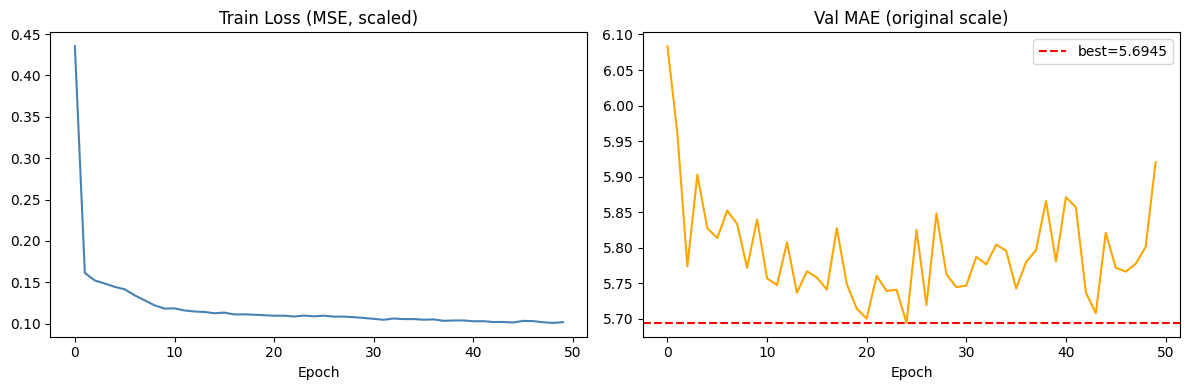

In [17]:
# Кривые обучения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, color='steelblue')
axes[0].set_title('Train Loss (MSE, scaled)')
axes[0].set_xlabel('Epoch')
axes[1].plot(val_maes, color='orange')
axes[1].axhline(best_val_mae, color='red', linestyle='--', label=f'best={best_val_mae:.4f}')
axes[1].set_title('Val MAE (original scale)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

In [18]:
# Val-метрики GRU
r1_val = compute_metrics(trues_val, preds_val)
print('R1 val:', r1_val)

R1 val: {'mae': 5.920440196990967, 'rmse': np.float64(7.654529113439071), 'mape': 3.911171481013298}


## 10. Финальная оценка лучшей модели на test


In [19]:
# Загружаем лучшие веса
model.load_state_dict(torch.load('artifacts/best_gru.pt', map_location=DEVICE))
model.eval()

preds_test_s, trues_test_s = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        p  = model(xb).cpu().numpy()
        preds_test_s.extend(p)
        trues_test_s.extend(yb.numpy())

preds_test_gru = scaler_y.inverse_transform(np.array(preds_test_s).reshape(-1,1)).flatten()
trues_test_gru = scaler_y.inverse_transform(np.array(trues_test_s).reshape(-1,1)).flatten()

r1_test = compute_metrics(trues_test_gru, preds_test_gru)
print('R1 test:', r1_test)

R1 test: {'mae': 6.786229610443115, 'rmse': np.float64(8.434449951472041), 'mape': 4.3391890823841095}


## 11. Сравнение моделей


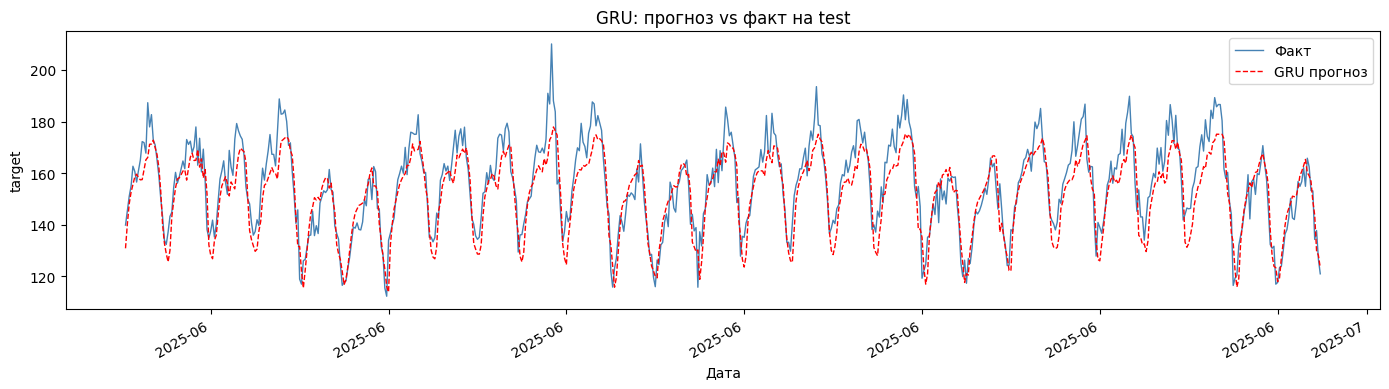

In [20]:
# График прогноза на test
# test_ds.targets содержит абсолютные индексы в df_feat
test_dates = df_feat.loc[test_ds.targets, 'date'].values

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_dates, trues_test_gru, label='Факт', color='steelblue', lw=1)
ax.plot(test_dates, preds_test_gru, label='GRU прогноз', color='red', lw=1, linestyle='--')
ax.set_title('GRU: прогноз vs факт на test')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()


In [21]:
results = {
    'B1 (naive-last)':      b1_val,
    'B2 (moving-average)':  b2_val,
    'B3 (ridge-lag)':       b3_val,
    'R1 (gru-forecast)':    r1_val,
}

df_res = pd.DataFrame(results).T.rename(columns={'mae':'MAE','rmse':'RMSE','mape':'MAPE(%)'})
print(df_res.round(4))

# выбор лучшей модели по val MAE
best_model_name = df_res['MAE'].idxmin()
print(f'\nЛучшая модель по val MAE: {best_model_name}')

                         MAE     RMSE  MAPE(%)
B1 (naive-last)       6.4434   8.2035   4.3946
B2 (moving-average)  12.7237  15.2363   8.8288
B3 (ridge-lag)        6.3412   7.9352   4.2457
R1 (gru-forecast)     5.9204   7.6545   3.9112

Лучшая модель по val MAE: R1 (gru-forecast)


/tmp/ipykernel_5928/3657004082.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=15, ha='right')


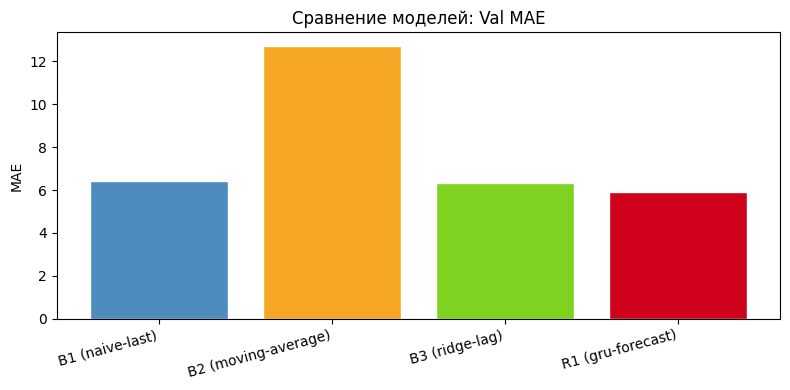

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
models = list(results.keys())
maes   = [results[m]['mae'] for m in models]
colors = ['#4C8CBF', '#F5A623', '#7ED321', '#D0021B']
ax.bar(models, maes, color=colors, edgecolor='white')
ax.set_title('Сравнение моделей: Val MAE')
ax.set_ylabel('MAE')
ax.set_xticklabels(models, rotation=15, ha='right')
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150)
plt.show()

## 12. Запись runs.csv и конфига GRU


In [23]:
split_summary = (
    f"train:{df_train_f['date'].min().date()}/{df_train_f['date'].max().date()} "
    f"val:{df_val_f['date'].min().date()}/{df_val_f['date'].max().date()} "
    f"test:{df_test_f['date'].min().date()}/{df_test_f['date'].max().date()}"
)

rows = [
    dict(
        experiment_id='B1', task='forecasting', dataset='S12-hw-dataset.csv',
        seed=SEED, split_summary=split_summary,
        window_size='', horizon=1, model_summary='naive-last',
        features_summary='lag_1', scaler='', optimizer='', lr='', epochs_trained='',
        best_val_mae=round(b1_val['mae'],4), best_val_rmse=round(b1_val['rmse'],4),
        best_val_mape=round(b1_val['mape'],4),
        test_mae='', test_rmse='', test_mape='', notes=''
    ),
    dict(
        experiment_id='B2', task='forecasting', dataset='S12-hw-dataset.csv',
        seed=SEED, split_summary=split_summary,
        window_size=7, horizon=1, model_summary='moving-average-7',
        features_summary='rolling_mean_7', scaler='', optimizer='', lr='', epochs_trained='',
        best_val_mae=round(b2_val['mae'],4), best_val_rmse=round(b2_val['rmse'],4),
        best_val_mape=round(b2_val['mape'],4),
        test_mae='', test_rmse='', test_mape='', notes=''
    ),
    dict(
        experiment_id='B3', task='forecasting', dataset='S12-hw-dataset.csv',
        seed=SEED, split_summary=split_summary,
        window_size='', horizon=1, model_summary='Ridge(alpha=1.0)',
        features_summary='lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,day_of_week,month,day_of_month',
        scaler='StandardScaler', optimizer='', lr='', epochs_trained='',
        best_val_mae=round(b3_val['mae'],4), best_val_rmse=round(b3_val['rmse'],4),
        best_val_mape=round(b3_val['mape'],4),
        test_mae='', test_rmse='', test_mape='', notes=''
    ),
    dict(
        experiment_id='R1', task='forecasting', dataset='S12-hw-dataset.csv',
        seed=SEED, split_summary=split_summary,
        window_size=WINDOW_SIZE, horizon=1,
        model_summary=f'GRU(hidden={HIDDEN_SIZE},layers={NUM_LAYERS})',
        features_summary='target_scaled',
        scaler='StandardScaler(target)', optimizer='Adam', lr=LR, epochs_trained=EPOCHS,
        best_val_mae=round(r1_val['mae'],4), best_val_rmse=round(r1_val['rmse'],4),
        best_val_mape=round(r1_val['mape'],4),
        test_mae=round(r1_test['mae'],4), test_rmse=round(r1_test['rmse'],4),
        test_mape=round(r1_test['mape'],4),
        notes='best model selected by val MAE'
    ),
]

df_runs = pd.DataFrame(rows)
df_runs.to_csv('artifacts/runs.csv', index=False)
print('runs.csv saved')
df_runs

runs.csv saved


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,train:2025-01-01/2025-05-07 val:2025-05-07/202...,,1,naive-last,lag_1,,,,,6.4434,8.2035,4.3946,,,,
1,B2,forecasting,S12-hw-dataset.csv,42,train:2025-01-01/2025-05-07 val:2025-05-07/202...,7,1,moving-average-7,rolling_mean_7,,,,,12.7237,15.2363,8.8288,,,,
2,B3,forecasting,S12-hw-dataset.csv,42,train:2025-01-01/2025-05-07 val:2025-05-07/202...,,1,Ridge(alpha=1.0),"lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_...",StandardScaler,,,,6.3412,7.9352,4.2457,,,,
3,R1,forecasting,S12-hw-dataset.csv,42,train:2025-01-01/2025-05-07 val:2025-05-07/202...,14,1,"GRU(hidden=64,layers=2)",target_scaled,StandardScaler(target),Adam,0.001,50,5.9204,7.6545,3.9112,6.7862,8.4344,4.3392,best model selected by val MAE


In [24]:
gru_config = dict(
    model='GRUForecaster',
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=0.2,
    window_size=WINDOW_SIZE,
    horizon=1,
    batch_size=BATCH_SIZE,
    lr=LR,
    epochs=EPOCHS,
    seed=SEED,
    scaler='StandardScaler(target)',
    best_val_mae=round(best_val_mae, 4)
)
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(gru_config, f, indent=2)
print('best_gru_config.json saved')

best_gru_config.json saved


## 13. Обсуждение утечек данных

Возможные точки утечки и как они предотвращены в данной работе:

| Риск | Статус |
|------|--------|
| `StandardScaler` обучен на всём датасете | ✅ Fit только на `train` |
| Rolling/lag признаки используют текущее значение | ✅ Все rolling строятся через `shift(1)` |
| Данные перемешаны перед split | ✅ Используется temporal split без shuffle |
| Test использован для подбора гиперпараметров | ✅ Hyperparameter selection по `val`; test — один раз |
| GRU DataLoader с shuffle=True на val/test | ✅ shuffle=False для val/test |
